# Unique Categories

## Definition

**Unique categories** are the different distinct values present in a categorical column.

### Example

Suppose a hospital dataset has:

```text
Department
-----------
Cardiology
Neurology
Cardiology
Orthopedics
Neurology
```

The unique categories are:

```text
Cardiology
Neurology
Orthopedics
```

So, there are **3 unique categories**.

## Why do we check Unique Categories?

During EDA, we check unique categories to understand:

* What categories exist?
* Are there unexpected or incorrect categories?
* How many different categories are present?
* Is the feature suitable for encoding?

## Python

```python
# Display unique categories
df["Department"].unique()
```

```python
# Count unique categories
df["Department"].nunique()
```

### Example Output

```text
['Cardiology', 'Neurology', 'Orthopedics']
```

```text
3
```

## AI/ML Perspective

Before encoding a categorical feature, we should know **which categories are present** and **how many categories exist**.

This helps us later identify:

* Low cardinality
* High cardinality
* Rare categories
* Category imbalance


# Category Frequencies

## Definition

**Category frequency** is the number of times each category appears in a categorical column.

It tells us **how many observations belong to each category**.

### Example

Suppose a hospital dataset has:

```text
Department
-----------
Cardiology
Neurology
Cardiology
Orthopedics
Neurology
Cardiology
```

The category frequencies are:

```text
Cardiology     3
Neurology      2
Orthopedics    1
```

## Python

```python
df["Department"].value_counts()
```

### Output

```text
Cardiology     3
Neurology      2
Orthopedics    1
Name: Department, dtype: int64
```

## Why do we check Category Frequencies?

During EDA, category frequencies help us identify:

* Which category occurs most often?
* Which category occurs least often?
* Whether some categories are rare
* Whether the data is balanced or imbalanced

## Real-World Example

In a customer dataset:

```text
Payment_Method
--------------
UPI
UPI
Credit Card
UPI
Cash
Credit Card
```

Frequency:

```text
UPI            3
Credit Card    2
Cash           1
```

So, **UPI is the most frequent category**.

## AI/ML Perspective

Category frequencies help us decide whether categories need special treatment before model training.

For example, a category appearing only a few times may be considered a **rare category** and may need to be grouped with other categories.


# Category Distribution

## Definition

**Category distribution** shows how the observations are distributed across the different categories of a categorical variable.

It tells us **what percentage or proportion of the data belongs to each category**.

### Example

Suppose a hospital dataset contains:

```text
Department
-----------
Cardiology
Cardiology
Neurology
Cardiology
Orthopedics
Neurology
```

Frequencies:

```text
Cardiology     3
Neurology      2
Orthopedics    1
```

Total observations = **6**

Distribution:

```text
Cardiology     50.0%
Neurology      33.3%
Orthopedics    16.7%
```

## Python

```python
df["Department"].value_counts(normalize=True) * 100
```

### Output

```text
Cardiology      50.0
Neurology       33.3
Orthopedics     16.7
```


## Why do we check Category Distribution?

During EDA, it helps us understand:

* Which categories dominate the dataset?
* Which categories have fewer observations?
* Whether categories are evenly distributed
* Whether the feature has a potential imbalance problem

## AI/ML Perspective

Category distribution is important because a heavily dominant category can influence the model.

For example:

```text
Payment Method
UPI            90%
Credit Card     8%
Cash            2%
```

Here, **UPI dominates the feature**.

This may indicate a **category imbalance**, which should be investigated before model training.


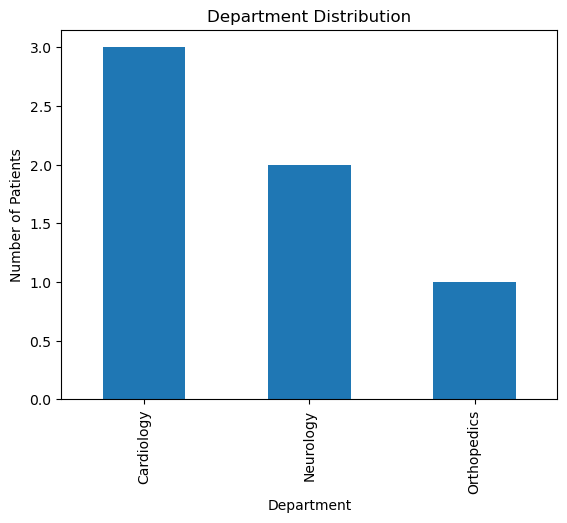

In [2]:

## Visualization

## A bar plot can be used to understand category distribution:
import pandas as pd 

df = pd.DataFrame({ "Department": [ "Cardiology", "Cardiology", "Neurology", "Cardiology", "Orthopedics", "Neurology" ] }) 
import matplotlib.pyplot as plt

df["Department"].value_counts().plot(kind="bar")

plt.xlabel("Department")
plt.ylabel("Number of Patients")
plt.title("Department Distribution")
plt.show()


# Rare Categories

## Definition

A **rare category** is a category that appears only a very small number of times compared with the other categories in a categorical feature.

### Example

Suppose a hospital dataset contains:

```text
Department
-----------
Cardiology
Cardiology
Cardiology
Neurology
Neurology
Orthopedics
Dermatology
Dermatology
Oncology
```

Frequencies:

```text
Cardiology      3
Neurology       2
Dermatology     2
Orthopedics     1
Oncology        1
```

Here, **Orthopedics** and **Oncology** are rare categories because they occur only once.

## How to Identify Rare Categories

We can check category frequencies:

```python
df["Department"].value_counts()
```

We can also calculate percentages:

```python
df["Department"].value_counts(normalize=True) * 100
```

For example:

```text
Cardiology      33.3%
Neurology       22.2%
Dermatology     22.2%
Orthopedics     11.1%
Oncology        11.1%
```

## Why do we check Rare Categories?

During EDA, rare categories can indicate:

* Very few observations
* Data-entry issues
* Unusual cases
* Categories that may not provide enough information for the model

## What can we do with Rare Categories?

Depending on the situation, we can:

* Keep the category if it is meaningful
* Combine similar categories
* Group very rare categories into `"Other"`
* Remove the category only when it is invalid or irrelevant

### Example

```python
df["Department"] = df["Department"].replace(
    ["Orthopedics", "Oncology"],
    "Other"
)
```

## AI/ML Perspective

Rare categories can create problems during encoding because the model gets very few examples to learn from.

Therefore, during EDA, we should **identify rare categories before encoding categorical features**.


# High Cardinality

## Definition

**High cardinality** means a categorical feature contains a **large number of unique categories**.

### Example

Suppose a customer dataset has:

```text
Customer_ID
-----------
C001
C002
C003
C004
C005
...
C10000
```

If there are **10,000 customers** and almost every `Customer_ID` is different, the feature has **high cardinality**.

```python
df["Customer_ID"].nunique()
```

Output:

```text
10000
```

## Common Examples

Features that can have high cardinality:

* Customer ID
* Employee ID
* Product ID
* Transaction ID
* ZIP/PIN code
* City
* Email address

## Why do we check High Cardinality?

High-cardinality features can cause:

* Too many encoded columns
* Increased memory usage
* More complex models
* Sparse data
* Overfitting

### Example

If a feature has:

```text
City = 5 categories
```

One-hot encoding creates only a few columns.

But if:

```text
City = 5,000 categories
```

One-hot encoding can create thousands of columns.


## AI/ML Perspective

Before encoding categorical features, we should check their cardinality.

For high-cardinality features, we may consider techniques such as:

* Frequency encoding
* Target encoding
* Feature hashing
* Grouping rare categories
* Removing ID-like features when they do not provide useful predictive information

**Important:** An identifier such as `Customer_ID` usually should **not** be treated as a normal categorical feature because each value may uniquely identify one record.


In [3]:

## Python

import pandas as pd

df = pd.DataFrame({
    "Customer_ID": ["C001", "C002", "C003", "C004", "C005"],
    "City": ["Chennai", "Bangalore", "Chennai", "Mumbai", "Bangalore"]
})

print("Customer_ID:", df["Customer_ID"].nunique())
print("City:", df["City"].nunique())

##Here, `Customer_ID` has higher cardinality than `City`.

Customer_ID: 5
City: 3


# Low Cardinality

## Definition

**Low cardinality** means a categorical feature contains a **small number of unique categories**.

### Example

Suppose a hospital dataset has:

```text
Gender
------
Male
Female
Male
Female
Male
```

There are only **2 unique categories**:

```python
df["Gender"].nunique()
```

Output:

```text
2
```

Therefore, `Gender` is a **low-cardinality categorical feature**.

## Common Examples

Features that usually have low cardinality:

* Gender
* Blood Group
* Yes/No
* Marital Status
* Payment Type
* Department
* Employment Type

### Example

```text
Blood_Group
-----------
A+
B+
O+
AB+
```

Only 4 categories exist, so this is a low-cardinality feature.

## Why do we check Low Cardinality?

Low-cardinality features are generally easier to:

* Analyze
* Visualize
* Encode
* Use in ML models

For example, **one-hot encoding** works well when a categorical feature has only a few categories.

## AI/ML Perspective

Low-cardinality categorical features are usually suitable for **One-Hot Encoding**.

For example:

```text
Payment_Method
--------------
UPI
Card
Cash
```

Can become:

```text
Payment_Method_UPI
Payment_Method_Card
Payment_Method_Cash
```

So, low cardinality generally makes categorical feature encoding **simple and manageable**.


In [6]:

## Python

import pandas as pd

df = pd.DataFrame({
    "Gender": ["Male", "Female", "Male", "Female", "Male"],
    "Payment_Method": ["UPI", "Cash", "UPI", "Card", "UPI"]
})

print(df["Gender"].nunique())
print(df["Payment_Method"].nunique())



2
3


# Category Imbalance

## Definition

**Category imbalance** occurs when one or more categories contain **many more observations than the other categories**.

### Example

Suppose a hospital dataset contains:

```text
Payment_Method
--------------
UPI
UPI
UPI
UPI
UPI
Credit Card
Cash
```

Frequencies:

```text
UPI             5
Credit Card     1
Cash            1
```

Here, **UPI is the dominant category**, while `Credit Card` and `Cash` have very few observations.

This is called **category imbalance**.


## Check the Distribution

```python
df["Payment_Method"].value_counts(normalize=True) * 100
```

### Output

```text
UPI            71.43%
Credit Card    14.29%
Cash           14.29%
```

Here, more than **70% of the observations belong to UPI**.

## Why do we check Category Imbalance?

During EDA, category imbalance helps us identify:

* Dominant categories
* Underrepresented categories
* Potential problems during model training
* Whether some categories need further investigation

## Important Difference

**Category imbalance** and **class imbalance** are related but not exactly the same.

* **Category imbalance** → imbalance within an input categorical feature.
* **Class imbalance** → imbalance in the **target variable**.

Example:

```text
Payment_Method → category imbalance
Loan_Approved  → class imbalance
```

## AI/ML Perspective

Category imbalance can cause the model to see some categories much more frequently than others.

For a categorical **feature**, we usually investigate whether the rare categories contain enough useful information.

For a categorical **target**, class imbalance can directly affect model performance and may require techniques such as:

* Class weights
* Oversampling
* Undersampling
* Appropriate evaluation metrics


In [ ]:

## Python

```python
import pandas as pd

df = pd.DataFrame({
    "Payment_Method": [
        "UPI",
        "UPI",
        "UPI",
        "UPI",
        "UPI",
        "Credit Card",
        "Cash"
    ]
})

df["Payment_Method"].value_counts()
```

### Output

```text
UPI            5
Credit Card    1
Cash           1
```